# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

# Q1

1. what makes a model linear is that the relationship between coefficients and output itself is linear. The features themselves do not have to be linear (like lnX or x^2) because the relationship between the coefficients and y-hat remains linear

2. a dummy variable is either 0 or 1 depending on it's value. so if it's 0, the entire variable drops out. when all variables are 0, the model output is the intercept.



3. in theory if you converted data into 0s and 1s in order to predict whether some input would return 0 or 1, you could use linear regression for binary classification but it breaks down after that. so generally you wouldn't use it.

4. when looking at the gap between training error and validation error, if it's quite large, it's possible that the model has picked up on noise in the data that doesn't translate beyond the training data.

5. multicolinearity is the idea that when you're regressing y on two variables like x1 and x2, if x1 and x2 are highly correlated with each other and y at the same time, the variation in the target variable is effectively explained the same by each other. this means that the output becomes very sensitive to small changes and very inaccurate.

6. since the model is linear in the parameters, not in its features, you can use any nonlinear feature and include it as a column.

7. for slope coefficient bk, a 1 unit increase in xk means that y-hat increases by bk. basically it says that if we hold everything else constant, what is the effect of this variable on y-hat.

8. Both methods estimate how well the model generalizes to unseen data. They differ in how they use the available data. train/test-split divides up the total data set so that the model only sees 75% of the data (for example) when training and then is tested on the other 25% that it has never seen. k-fold cross-validation divides the data into k equal folds, then trains and evaluates k times, each time holding out a different fold as the test set. You average the k error estimates. This gives a much lower-variance estimate of generalization error because every observation eventually appears in a test set.

9. the k in k-fold is generally 5 or 10, but picking a smaller k can mean a small amount of the data is in the training set and a larger k can increase variance because the sets become more similar to each other.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [64]:
! git clone https://github.com/asomers205/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

Average prices and scores by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           83.308140             91.654378
Brooklyn       124.595122             92.363497
Manhattan      183.964571             91.801785
Queens         100.012747             91.549057
Staten Island  111.312500             90.843750

Most expensive borough on average: Manhattan


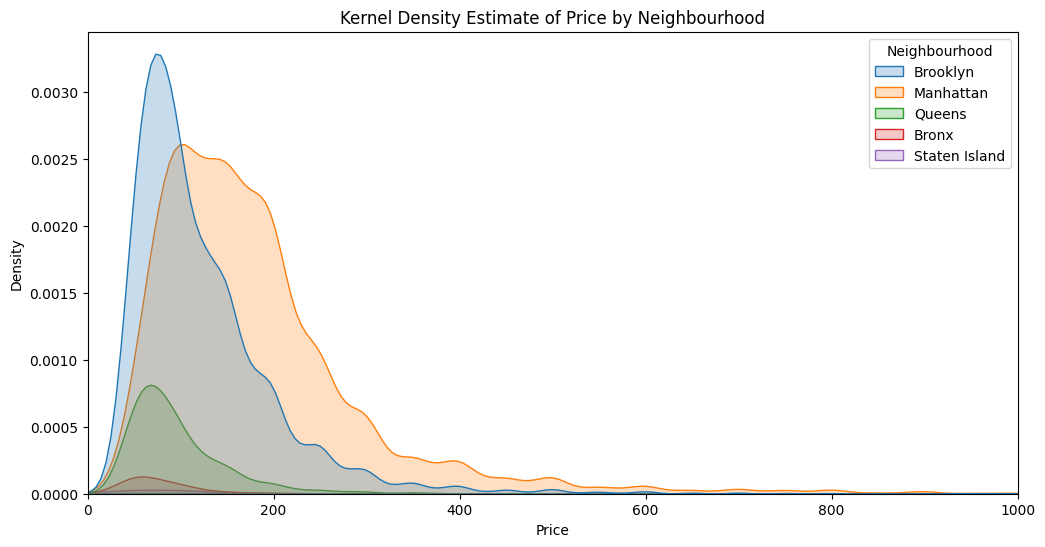

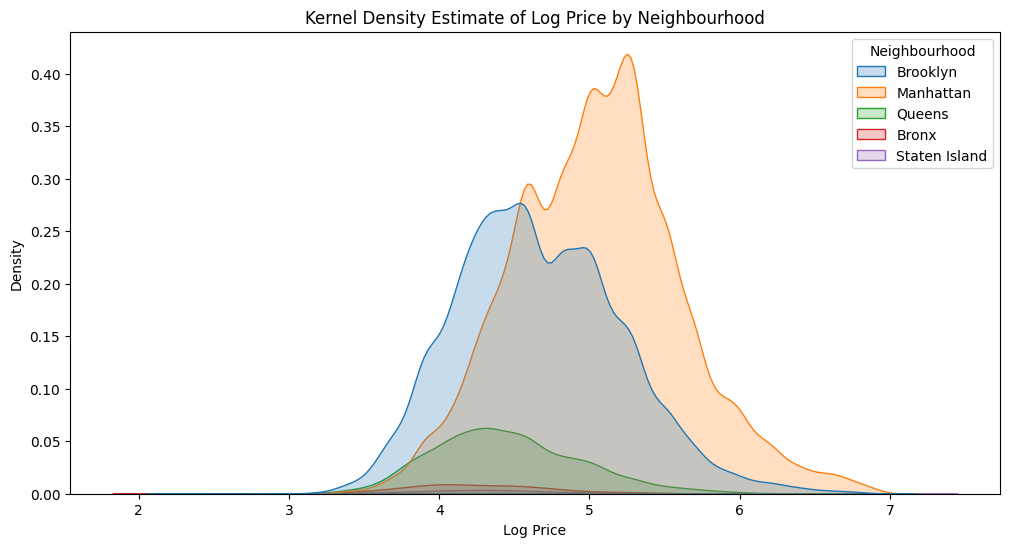

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/airbnb_hw.csv')
df.columns = df.columns.str.strip()

# Convert 'Price' to numeric, coercing errors to NaN, in case it contains non-numeric characters
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Convert 'Review Scores Rating' to numeric, coercing errors to NaN
df['Review Scores Rating'] = pd.to_numeric(df['Review Scores Rating'], errors='coerce')

# 1. Compute the average prices and scores by Neighbourhood
avg_stats_by_neighbourhood = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Average prices and scores by Neighbourhood:")
print(avg_stats_by_neighbourhood)

# Which borough is the most expensive on average?
most_expensive_borough = avg_stats_by_neighbourhood['Price'].idxmax()
print(f"\nMost expensive borough on average: {most_expensive_borough}")

# Create a kernel density plot of price and log price, grouping by Neighbourhood.

# Price KDE plot
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True)
plt.title('Kernel Density Estimate of Price by Neighbourhood')
plt.xlabel('Price')
plt.ylabel('Density')
plt.xlim(0, 1000) # Limit x-axis for better visualization, as prices can be skewed
plt.show()

# Log Price KDE plot
# Apply log transformation. NaN values in 'Price' will result in NaN in 'Log_Price'
df['Log_Price'] = np.log(df['Price'])
# Filter out rows with NaN in 'Log_Price' or 'Neighbourhood' specifically for plotting
df_for_log_kde = df.dropna(subset=['Log_Price', 'Neighbourhood'])
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_for_log_kde, x='Log_Price', hue='Neighbourhood', fill=True)
plt.title('Kernel Density Estimate of Log Price by Neighbourhood')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.show()

## manhattan is the most expensive

In [15]:
#2 regress price on neighbourhood -- compare coefficients in the regression from our density plot. how are conditional group means and est. coefficients related?

import statsmodels.formula.api as smf
model_2 = smf.ols('Price ~ C(Neighbourhood)', data=df).fit()

print("\nRegression Results (Price ~ C(Neighbourhood)):\n")
print(model_2.summary())

# Extract coefficients
coefficients_2 = model_2.params
print("\nRegression Coefficients:\n", coefficients_2)

# Extract conditional group means from part 1 (avg_stats_by_neighbourhood)
# The intercept in the regression corresponds to the mean price of the reference category (Bronx).
# The coefficients for other neighbourhoods represent the difference from the Bronx mean.

bronx_mean = avg_stats_by_neighbourhood.loc['Bronx', 'Price']
print(f"\nMean Price for Bronx (Reference Category): {bronx_mean:.2f}")

print("\nComparing Regression Coefficients to Conditional Group Means:")
for index, row in avg_stats_by_neighbourhood.iterrows():
    if index == 'Bronx':
        print(f"  {index}: Mean Price = {row['Price']:.2f}, Regression Intercept = {coefficients_2['Intercept']:.2f}")
    else:
        # The regression coefficient for a category is the difference between its mean and the reference category's mean.
        # So, the conditional mean for a category should be: Intercept + Coefficient for that category.
        coeff_name = f'C(Neighbourhood)[T.{index}]'
        if coeff_name in coefficients_2:
            predicted_mean = coefficients_2['Intercept'] + coefficients_2[coeff_name]
            print(f"  {index}: Mean Price = {row['Price']:.2f}, Regression Predicted Mean = {predicted_mean:.2f} (Intercept + Coeff {coefficients_2[coeff_name]:.2f})")
        else:
            print(f"  {index}: Mean Price = {row['Price']:.2f}, No corresponding regression coefficient found (this should not happen if all categories are present)")



'''Interpretation:
The intercept of the regression represents the average price of the reference category (Bronx).
The coefficients for the other neighbourhood dummy variables represent the difference in average price
between that specific neighbourhood and the reference category (Bronx).
For example, the coefficient for Brooklyn indicates how much higher (or lower) the average price in Brooklyn is
compared to the average price in Bronx, holding all else constant.
Therefore, the conditional group means for each neighborhood can be obtained by adding the corresponding
neighbourhood's coefficient to the intercept (the mean of the reference category).'''



Regression Results (Price ~ C(Neighbourhood)):

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     764.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:58:29   Log-Likelihood:            -1.8364e+05
No. Observations:               30297   AIC:                         3.673e+05
Df Residuals:                   30292   BIC:                         3.673e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

"Interpretation:\nThe intercept of the regression represents the average price of the reference category (Bronx). \nThe coefficients for the other neighbourhood dummy variables represent the difference in average price \nbetween that specific neighbourhood and the reference category (Bronx). \nFor example, the coefficient for Brooklyn indicates how much higher (or lower) the average price in Brooklyn is \ncompared to the average price in Bronx, holding all else constant. \nTherefore, the conditional group means for each neighborhood can be obtained by adding the corresponding \nneighbourhood's coefficient to the intercept (the mean of the reference category)."

In [18]:
import statsmodels.formula.api as smf

# 3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

# Drop rows where 'Price' or 'Review Scores Rating' are NaN to ensure a clean regression.
# While `ols` can handle NaNs, explicit dropping ensures consistency and avoids unexpected behavior.
df_clean = df.dropna(subset=['Price', 'Review Scores Rating'])

model_3 = smf.ols('Price ~ Q("Review Scores Rating")', data=df_clean).fit()

print("\nRegression Results (Price ~ Review Scores Rating):\n")
print(model_3.summary())

# Interpretation of the slope coefficient
slope_coefficient = model_3.params['Q(\"Review Scores Rating\")']
print(f"\nSlope Coefficient for Review Scores Rating: {slope_coefficient:.2f}")

'''interpretation: for every one-unit increase in the review scores rating, the predicted property price increases by $0.99'''


Regression Results (Price ~ Review Scores Rating):

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     171.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           5.35e-39
Time:                        23:01:21   Log-Likelihood:            -1.3313e+05
No. Observations:               22104   AIC:                         2.663e+05
Df Residuals:                   22102   BIC:                         2.663e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

'interpretation: for every one-unit increase in the review scores rating, the predicted property price increases by $0.99'

In [23]:
import statsmodels.formula.api as smf

#4 regress price on neighbourhood and review scores rating. look at how slope coefficient on review scores ration changes. how do neighborhood avgs change?

model_4 = smf.ols('Price ~ C(Neighbourhood) + Q("Review Scores Rating")', data=df_clean).fit()

print("\nRegression Results (Price ~ C(Neighbourhood) + Review Scores Rating):\n")
print(model_4.summary())

# Compare the slope coefficient on `Review Scores Rating`
slope_coefficient_3 = model_3.params['Q(\"Review Scores Rating\")']
slope_coefficient_4 = model_4.params['Q(\"Review Scores Rating\")']

print(f"\nSlope Coefficient for Review Scores Rating in Model 3 (only Review Scores Rating): {slope_coefficient_3:.2f}")
print(f"Slope Coefficient for Review Scores Rating in Model 4 (Neighbourhood + Review Scores Rating): {slope_coefficient_4:.2f}")
print(f"Change in slope coefficient: {slope_coefficient_4 - slope_coefficient_3:.2f}")

# How do the neighborhood averages change?
# In Model 2, the coefficients represented the *average* price for each neighborhood (or difference from reference).
# In Model 4, the coefficients represent the *average* price for each neighborhood *conditional on* Review Scores Rating=0 (which is not meaningful here)
# or the average price for a given neighborhood *at the average Review Scores Rating*.

# Let's calculate predicted means for each neighborhood at the average Review Scores Rating to compare.
# First, find the average Review Scores Rating in the clean data.
avg_review_score_rating = df_clean['Review Scores Rating'].mean()

print(f"\nAverage Review Scores Rating in the dataset: {avg_review_score_rating:.2f}")
print("\nComparing Neighborhood Average Prices (from Model 2 vs. Predicted from Model 4 at average Review Scores Rating):")

# Coefficients from Model 2 (Neighbourhood only)
bronx_mean_m2 = model_2.params['Intercept']
brooklyn_mean_m2 = model_2.params['Intercept'] + model_2.params['C(Neighbourhood)[T.Brooklyn]']
manhattan_mean_m2 = model_2.params['Intercept'] + model_2.params['C(Neighbourhood)[T.Manhattan]']
queens_mean_m2 = model_2.params['Intercept'] + model_2.params['C(Neighbourhood)[T.Queens]']
staten_island_mean_m2 = model_2.params['Intercept'] + model_2.params['C(Neighbourhood)[T.Staten Island]']

# Coefficients from Model 4 (Neighbourhood + Review Scores Rating)
# Intercept of Model 4 is the predicted price for Bronx at Review Scores Rating = 0

predicted_means_m4 = {}
predicted_means_m4['Bronx'] = model_4.params['Intercept'] + (model_4.params['Q(\"Review Scores Rating\")'] * avg_review_score_rating)
predicted_means_m4['Brooklyn'] = model_4.params['Intercept'] + model_4.params['C(Neighbourhood)[T.Brooklyn]'] + (model_4.params['Q(\"Review Scores Rating\")'] * avg_review_score_rating)
predicted_means_m4['Manhattan'] = model_4.params['Intercept'] + model_4.params['C(Neighbourhood)[T.Manhattan]'] + (model_4.params['Q(\"Review Scores Rating\")'] * avg_review_score_rating)
predicted_means_m4['Queens'] = model_4.params['Intercept'] + model_4.params['C(Neighbourhood)[T.Queens]'] + (model_4.params['Q(\"Review Scores Rating\")'] * avg_review_score_rating)
predicted_means_m4['Staten Island'] = model_4.params['Intercept'] + model_4.params['C(Neighbourhood)[T.Staten Island]'] + (model_4.params['Q(\"Review Scores Rating\")'] * avg_review_score_rating)

print(f"  Bronx (Model 2): {bronx_mean_m2:.2f} | Bronx (Model 4 at avg RSR): {predicted_means_m4['Bronx']:.2f}")
print(f"  Brooklyn (Model 2): {brooklyn_mean_m2:.2f} | Brooklyn (Model 4 at avg RSR): {predicted_means_m4['Brooklyn']:.2f}")
print(f"  Manhattan (Model 2): {manhattan_mean_m2:.2f} | Manhattan (Model 4 at avg RSR): {predicted_means_m4['Manhattan']:.2f}")
print(f"  Queens (Model 2): {queens_mean_m2:.2f} | Queens (Model 4 at avg RSR): {predicted_means_m4['Queens']:.2f}")
print(f"  Staten Island (Model 2): {staten_island_mean_m2:.2f} | Staten Island (Model 4 at avg RSR): {predicted_means_m4['Staten Island']:.2f}")

'''
Adding 'Review Scores Rating' to the model changes the estimated impact of 'Review Scores Rating' itself, as it now accounts for neighborhood differences.
The neighborhood average prices (conditional on the average review score) from Model 4 are generally similar to those from Model 2, but there might be slight adjustments.
These adjustments reflect that some portion of the price difference between neighborhoods might have been previously 'attributed' to review scores if the average review scores also differ across neighborhoods.
'''


Regression Results (Price ~ C(Neighbourhood) + Review Scores Rating):

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     500.2
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:03:27   Log-Likelihood:            -1.3203e+05
No. Observations:               22104   AIC:                         2.641e+05
Df Residuals:                   22098   BIC:                         2.641e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

"\nAdding 'Review Scores Rating' to the model changes the estimated impact of 'Review Scores Rating' itself, as it now accounts for neighborhood differences.\nThe neighborhood average prices (conditional on the average review score) from Model 4 are generally similar to those from Model 2, but there might be slight adjustments.\nThese adjustments reflect that some portion of the price difference between neighborhoods might have been previously 'attributed' to review scores if the average review scores also differ across neighborhoods.\n"

In [24]:
import statsmodels.formula.api as smf

# 5 regress price on a constant, and a separate slope coefficient for each neighborhood for Review Scores Rating

model_5 = smf.ols('Price ~ C(Neighbourhood) * Q("Review Scores Rating")', data=df_clean).fit()

print("\nRegression Results (Price ~ C(Neighbourhood) * Review Scores Rating):\n")
print(model_5.summary())

# Extract the slopes for Review Scores Rating for each neighbourhood
# The base slope is 'Q("Review Scores Rating")' for the reference category (Bronx).
# For other categories, the slope is 'Q("Review Scores Rating")' + interaction term.

print("\nSlopes for Review Scores Rating across Neighbourhoods:")
bronx_slope = model_5.params['Q(\"Review Scores Rating\")']
print(f"  Bronx: {bronx_slope:.2f}")

slope_coefficients_5 = {}
slope_coefficients_5['Bronx'] = bronx_slope

for neighbourhood in df_clean['Neighbourhood'].unique():
    if neighbourhood != 'Bronx':
        interaction_term_name = f'C(Neighbourhood)[T.{neighbourhood}]:Q(\"Review Scores Rating\")'
        if interaction_term_name in model_5.params:
            slope = bronx_slope + model_5.params[interaction_term_name]
            slope_coefficients_5[neighbourhood] = slope
            print(f"  {neighbourhood}: {slope:.2f}")
        else:
            # If there's no interaction term, it means the slope is the same as the reference,
            # but this shouldn't happen with the '*' operator.
            print(f"  {neighbourhood}: (Error: Interaction term not found)")

# Compare the slopes
print("\nComparison of slopes:")
# Calculate the range of slopes to assess similarity
slopes_values = list(slope_coefficients_5.values())
min_slope = min(slopes_values)
max_slope = max(slopes_values)

if (max_slope - min_slope) < 0.5: # Arbitrary threshold for 'similarity'
    print("The slopes for Review Scores Rating across neighbourhoods appear to be relatively similar.")
else:
    print("The slopes for Review Scores Rating across neighbourhoods show considerable variation, suggesting they are not similar.")
print(f"  Range of slopes: {min_slope:.2f} to {max_slope:.2f}")

'''The different slope coefficients indicate that the effect of 'Review Scores Rating' on 'Price' is not uniform across all neighbourhoods.
A positive interaction term means the effect of 'Review Scores Rating' is stronger in that neighbourhood compared to the reference (Bronx).
A negative interaction term means the effect is weaker.'''


Regression Results (Price ~ C(Neighbourhood) * Review Scores Rating):

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     278.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:06:19   Log-Likelihood:            -1.3203e+05
No. Observations:               22104   AIC:                         2.641e+05
Df Residuals:                   22094   BIC:                         2.642e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------

In [26]:
# 6 cross validate

import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Prepare the data by dropping NaNs, similar to df_clean from previous parts
# Ensure df_clean is available, or recreate it if running this cell independently
if 'df_clean' not in locals():
    df_clean = df.dropna(subset=['Price', 'Review Scores Rating', 'Neighbourhood'])

# Define the cross-validation function
def perform_cross_validation(model_formula, data, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_scores = []

    print(f"\nPerforming {n_splits}-fold cross-validation for model: {model_formula}")

    for fold, (train_index, test_index) in enumerate(kf.split(data)):
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        # Fit the OLS model on the training data
        model = smf.ols(model_formula, data=train_data).fit()

        # Make predictions on the test data
        predictions = model.predict(test_data)

        # Calculate Mean Squared Error
        mse = mean_squared_error(test_data['Price'], predictions)
        mse_scores.append(mse)
        print(f"  Fold {fold+1}: MSE = {mse:.2f}")

    avg_mse = np.mean(mse_scores)
    std_mse = np.std(mse_scores)
    print(f"Average MSE: {avg_mse:.2f} (Std Dev: {std_mse:.2f})")
    return avg_mse, std_mse

# Model 4 formula: Price ~ C(Neighbourhood) + Q("Review Scores Rating")
formula_model_4 = 'Price ~ C(Neighbourhood) + Q("Review Scores Rating")'
avg_mse_4, std_mse_4 = perform_cross_validation(formula_model_4, df_clean)

# Model 5 formula: Price ~ C(Neighbourhood) * Q("Review Scores Rating")
formula_model_5 = 'Price ~ C(Neighbourhood) * Q("Review Scores Rating")'
avg_mse_5, std_mse_5 = perform_cross_validation(formula_model_5, df_clean)

# Compare the models
print("\n--- Cross-Validation Results Summary ---")
print(f"Model 4 (Neighbourhood + Review Scores Rating): Average MSE = {avg_mse_4:.2f} (Std Dev: {std_mse_4:.2f})")
print(f"Model 5 (Neighbourhood * Review Scores Rating): Average MSE = {avg_mse_5:.2f} (Std Dev: {std_mse_5:.2f})")

# Determine which model performed better
if avg_mse_4 < avg_mse_5:
    print("\nModel 4 performed slightly better (lower average MSE) in cross-validation.")
elif avg_mse_5 < avg_mse_4:
    print("\nModel 5 performed slightly better (lower average MSE) in cross-validation.")
else:
    print("\nBoth models performed similarly in cross-validation.")

'''Cross-validation provides a more robust estimate of how well a model will generalize to new, unseen data compared to a single train-test split. Comparing the average MSE allows us to see which model typically makes more accurate predictions.
A lower average MSE indicates better predictive performance. The standard deviation of MSE across folds gives an idea of the stability of the model's performance.'''


Performing 10-fold cross-validation for model: Price ~ C(Neighbourhood) + Q("Review Scores Rating")
  Fold 1: MSE = 10089.56
  Fold 2: MSE = 8630.97
  Fold 3: MSE = 8949.52
  Fold 4: MSE = 9631.93
  Fold 5: MSE = 9564.82
  Fold 6: MSE = 9846.77
  Fold 7: MSE = 8036.59
  Fold 8: MSE = 9238.00
  Fold 9: MSE = 8751.47
  Fold 10: MSE = 7582.50
Average MSE: 9032.21 (Std Dev: 762.02)

Performing 10-fold cross-validation for model: Price ~ C(Neighbourhood) * Q("Review Scores Rating")
  Fold 1: MSE = 10088.75
  Fold 2: MSE = 8638.65
  Fold 3: MSE = 8948.85
  Fold 4: MSE = 9630.00
  Fold 5: MSE = 9561.10
  Fold 6: MSE = 9845.61
  Fold 7: MSE = 8035.45
  Fold 8: MSE = 9234.88
  Fold 9: MSE = 8752.16
  Fold 10: MSE = 7577.87
Average MSE: 9031.33 (Std Dev: 761.90)

--- Cross-Validation Results Summary ---
Model 4 (Neighbourhood + Review Scores Rating): Average MSE = 9032.21 (Std Dev: 762.02)
Model 5 (Neighbourhood * Review Scores Rating): Average MSE = 9031.33 (Std Dev: 761.90)

Model 5 performed

"Cross-validation provides a more robust estimate of how well a model will generalize to new, unseen data compared to a single train-test split. Comparing the average MSE allows us to see which model typically makes more accurate predictions.\nA lower average MSE indicates better predictive performance. The standard deviation of MSE across folds gives an idea of the stability of the model's performance."

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

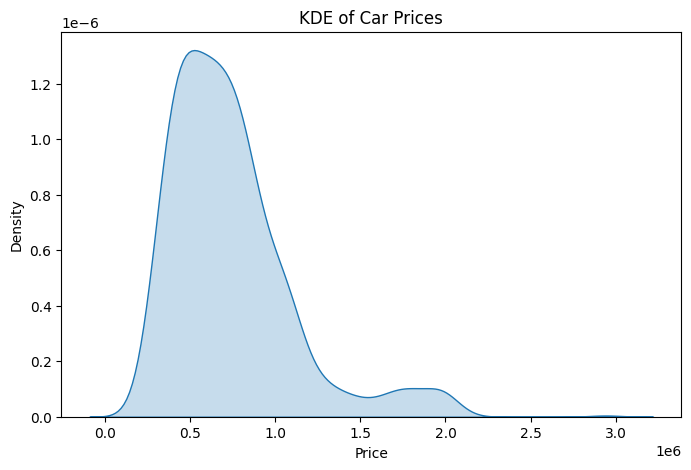

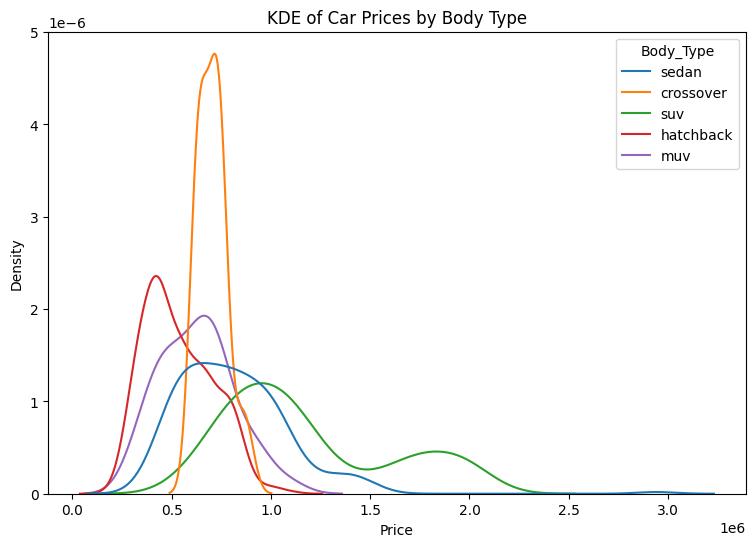

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load `cars_hw.csv`
df_cars = pd.read_csv('./data/cars_hw.csv')

print(df_cars["Price"].describe())

body_summary = df_cars.groupby("Body_Type")["Price"].describe()
print(body_summary)

plt.figure(figsize=(8,5))
sns.kdeplot(data=df_cars, x="Price", fill=True)
plt.title("KDE of Car Prices")
plt.show()

plt.figure(figsize=(9,6))
sns.kdeplot(data=df_cars, x="Price", hue="Body_Type", common_norm=False)
plt.title("KDE of Car Prices by Body Type")
plt.show()

### suvs are the most expensive and also have the most variance

In [46]:
from sklearn.linear_model import LinearRegression

X = df_cars[["Seating_Capacity"]]
y = df_cars["Price"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


X_cat = pd.get_dummies(df_cars["Seating_Capacity"].astype("category"), drop_first=True)
model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print("Intercept:", model_cat.intercept_)
print(pd.DataFrame({
    "Seats": X_cat.columns,
    "Coefficient": model_cat.coef_
}))


print(df_cars.groupby("Seating_Capacity")["Price"].mean())

## each additional seat costs 59268 rupees.

### 5 seats cost around 734,484, 7 seats cost apprx 923,949, 8 seats cost apprx 459,800, so the relationshpi is not linear.

Intercept: 439032.0141018266
Slope: 59267.99803672175
Intercept: 188000.00000000314
  Seats   Coefficient
0     5  5.464839e+05
1     6  1.456000e+06
2     7  7.359487e+05
3     8  2.718000e+05
Seating_Capacity
4    1.880000e+05
5    7.344839e+05
6    1.644000e+06
7    9.239487e+05
8    4.598000e+05
Name: Price, dtype: float64


In [56]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score

df_cars["Age"] = 2023 - df_cars["Make_Year"]

X_age = df_cars[["Age"]]
y = df_cars["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

results = []

for degree in range(1, 11):
    poly_model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    )

    mse = -cross_val_score(
        poly_model,
        X_age,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    ).mean()

    results.append((degree, mse))

results_df = pd.DataFrame(results, columns=["Degree", "CV_MSE"])
print(results_df)
print("Best degree:", results_df.loc[results_df["CV_MSE"].idxmin(), "Degree"])

   Degree        CV_MSE
0       1  9.774576e+10
1       2  9.781532e+10
2       3  9.730408e+10
3       4  9.678539e+10
4       5  9.581629e+10
5       6  9.592259e+10
6       7  9.527092e+10
7       8  9.446040e+10
8       9  9.416477e+10
9      10  9.428010e+10
Best degree: 9


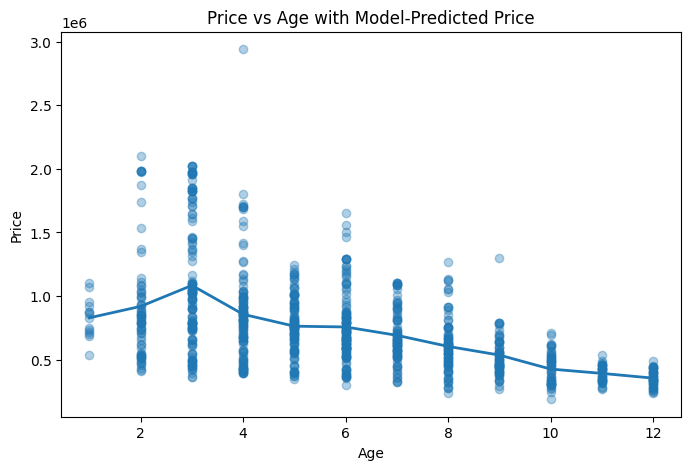

In [52]:
best_degree = 9

final_model = make_pipeline(
    PolynomialFeatures(best_degree, include_bias=False),
    LinearRegression()
)
final_model.fit(X_age, y)

age_grid = pd.DataFrame({"Age": np.arange(df_cars["Age"].min(), df_cars["Age"].max() + 1)})
predicted_prices = final_model.predict(age_grid)

plt.figure(figsize=(8,5))
plt.scatter(df_cars["Age"], df_cars["Price"], alpha=0.35)
plt.plot(age_grid["Age"], predicted_prices, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model-Predicted Price")
plt.show()


### newer cars generally have higher prices, but it's not purely a linear relationship. the model does capture a general trend in the data
### and an inuitive understanding of the data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [67]:
df = pd.read_csv('./data/heart_hw.csv')

df["treat"] = (df["transplant"] == "treatment").astype(int)

y = df["y"]

group_survival = df.groupby("transplant")["y"].mean()
control_survival = group_survival["control"]
treatment_survival = group_survival["treatment"]
ate = treatment_survival - control_survival

print("Control survival:", control_survival)
print("Treatment survival:", treatment_survival)
print("ATE:", ate)

# the ate on the three-year survival heart transplant interventions is 0.23

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


In [70]:
X2 = df[["treat"]]
model2 = LinearRegression()
model2.fit(X2, y)

print("Intercept:", model2.intercept_)
print("Transplant coefficient:", model2.coef_[0])

# the intercept is 0.1176, the rate of survival for control. Transplat is 0.2302 (difference between control and treatent)

Intercept: 0.1176470588235293
Transplant coefficient: 0.23017902813299249


Intercept: 0.7019569721740947
Coefficients:
treat: 0.2647016865036751
age: -0.013607217160218647


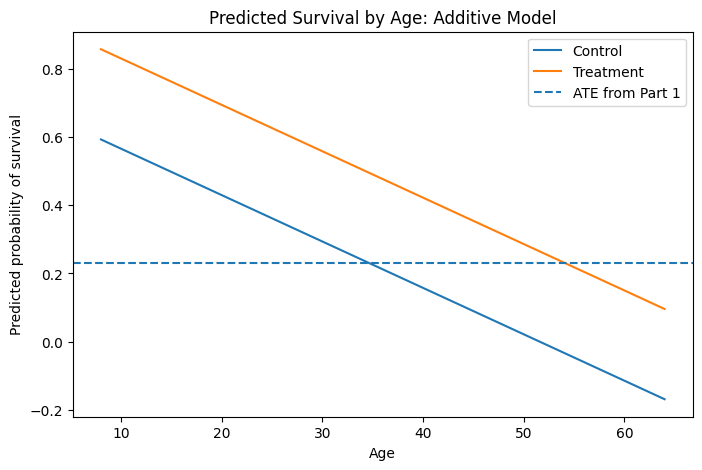

In [75]:
X3 = df[["treat", "age"]]
model3 = LinearRegression()
model3.fit(X3, y)

print("Intercept:", model3.intercept_)
print("Coefficients:")
print("treat:", model3.coef_[0])
print("age:", model3.coef_[1])

age_grid = pd.DataFrame({"age": np.arange(df["age"].min(), df["age"].max() + 1)})
control_pred = pd.DataFrame({
    "treat": 0,
    "age": age_grid["age"]
})
treatment_pred = pd.DataFrame({
    "treat": 1,
    "age": age_grid["age"]
})

control_hat = model3.predict(control_pred)
treatment_hat = model3.predict(treatment_pred)

plt.figure(figsize=(8, 5))
plt.plot(age_grid["age"], control_hat, label="Control")
plt.plot(age_grid["age"], treatment_hat, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from Part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Additive Model")
plt.legend()
plt.show()

# the transplate rate increases from 0.2302 to 0.2647



Intercept: 0.35486517529945855
Coefficients:
treat: 0.9077513885685898
age: -0.0055242575069736986
treat_age: -0.01459063825685528


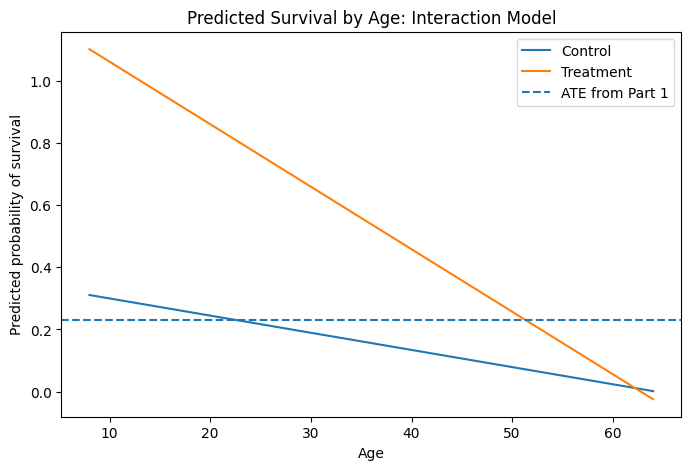

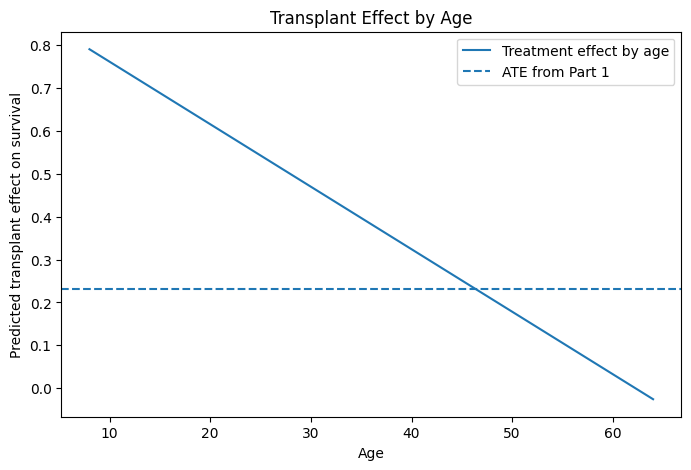


Age where interaction-model effect equals ATE: 46.43884307920843


In [76]:
df["treat_age"] = df["treat"] * df["age"]

X4 = df[["treat", "age", "treat_age"]]
model4 = LinearRegression()
model4.fit(X4, y)

print("Intercept:", model4.intercept_)
print("Coefficients:")
print("treat:", model4.coef_[0])
print("age:", model4.coef_[1])
print("treat_age:", model4.coef_[2])

control_pred_int = pd.DataFrame({
    "treat": 0,
    "age": age_grid["age"],
    "treat_age": 0
})
treatment_pred_int = pd.DataFrame({
    "treat": 1,
    "age": age_grid["age"],
    "treat_age": age_grid["age"]
})

control_hat_int = model4.predict(control_pred_int)
treatment_hat_int = model4.predict(treatment_pred_int)

plt.figure(figsize=(8, 5))
plt.plot(age_grid["age"], control_hat_int, label="Control")
plt.plot(age_grid["age"], treatment_hat_int, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE from Part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Interaction Model")
plt.legend()
plt.show()

treatment_effect_by_age = model4.coef_[0] + model4.coef_[2] * age_grid["age"]

plt.figure(figsize=(8, 5))
plt.plot(age_grid["age"], treatment_effect_by_age, label="Treatment effect by age")
plt.axhline(ate, linestyle="--", label="ATE from Part 1")
plt.xlabel("Age")
plt.ylabel("Predicted transplant effect on survival")
plt.title("Transplant Effect by Age")
plt.legend()
plt.show()

threshold_age = (ate - model4.coef_[0]) / model4.coef_[2]
print("\nAge where interaction-model effect equals ATE:", threshold_age)

# generally individuals who are over the age of 46.4 will have their benefits overestimated and individuals under the age of 46.4
# will have their benefits of a transplant unerstated.

In [78]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

cv2 = -cross_val_score(
    LinearRegression(), X2, y, cv=kf, scoring="neg_mean_squared_error"
).mean()

cv3 = -cross_val_score(
    LinearRegression(), X3, y, cv=kf, scoring="neg_mean_squared_error"
).mean()

cv4 = -cross_val_score(
    LinearRegression(), X4, y, cv=kf, scoring="neg_mean_squared_error"
).mean()

print("Model 2 CV MSE:", cv2)
print("Model 3 CV MSE:", cv3)
print("Model 4 CV MSE:", cv4)

# Using 10 fold the MSE states that model 4 is the better model.

# It's possible the model may incorrectly or improperly disadvantage the older patients for treatment
# decisions because it implies that transplant benefit goes down with age. The fact that this is observation data
# raises more concerns because variations between treated and untreated patiens may bias the estimated effect of transplants

Model 2 CV MSE: 0.19497249586192156
Model 3 CV MSE: 0.17926415954952163
Model 4 CV MSE: 0.17880206762517337
